# MedProc Visualization & Progress Dashboard
## Project Status, Metrics, and Performance Analysis

**Purpose:**
Track training progress, visualize model performance metrics, and analyze prediction quality for the MedProc pipeline.

**Contents:**
1. Load training history and logs
2. Performance metrics dashboard
3. Training convergence analysis
4. Prediction quality analysis
5. Model comparison and evaluation
6. Project roadmap and next steps

In [1]:
# Import libraries
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

OUTPUT_DIR = Path('/data/Stagewise Dataset/MedProc/final3')
CHECKPOINT_DIR = Path('/data/Stagewise Dataset/MedProc/checkpoints')

print('✓ Visualization environment ready')
print(f'  Output directory: {OUTPUT_DIR}')
print(f'  Checkpoint directory: {CHECKPOINT_DIR}')

✓ Visualization environment ready
  Output directory: /data/Stagewise Dataset/MedProc/final3
  Checkpoint directory: /data/Stagewise Dataset/MedProc/checkpoints


## Section 1: Project Status & Components

Overview of MedProc pipeline components and current status.

In [2]:
# Project components status
components = {
    'medproc_dataset.py': {
        'status': '✓ Complete',
        'description': 'Dataset loading, preprocessing, ICD filtering, symptom extraction',
        'functions': 8
    },
    'medproc_model.py': {
        'status': '✓ Complete',
        'description': 'Multi-task model architecture, training loops, checkpoint utilities',
        'functions': 10
    },
    'medproc_train.ipynb': {
        'status': '✓ Complete',
        'description': 'Training execution with 6 sections (data, model, train, eval, viz, predictions)',
        'sections': 6
    },
    'medproc_visualize.ipynb': {
        'status': '✓ Complete',
        'description': 'Progress dashboard and visualization utilities',
        'sections': 5
    },
    'medproc_full_pipeline.ipynb': {
        'status': '✓ Complete',
        'description': 'End-to-end pipeline with inference and batch prediction',
        'cells': 23
    },
}

print('=' * 80)
print('PROJECT COMPONENTS STATUS')
print('=' * 80)
for comp, info in components.items():
    print(f'\n{comp}')
    print(f'  Status: {info["status"]}')
    print(f'  Purpose: {info["description"]}')
    
# Check file existence
print('\n' + '=' * 80)
print('FILE INVENTORY')
print('=' * 80)
medproc_files = list(Path('/home/vjti-comp/Desktop/Final Project Code/MedProc').glob('*.py'))
medproc_files.extend(Path('/home/vjti-comp/Desktop/Final Project Code/MedProc').glob('*.ipynb'))

for f in sorted(medproc_files):
    size_kb = f.stat().st_size / 1024
    print(f'{f.name:40s} {size_kb:8.1f} KB')

PROJECT COMPONENTS STATUS

medproc_dataset.py
  Status: ✓ Complete
  Purpose: Dataset loading, preprocessing, ICD filtering, symptom extraction

medproc_model.py
  Status: ✓ Complete
  Purpose: Multi-task model architecture, training loops, checkpoint utilities

medproc_train.ipynb
  Status: ✓ Complete
  Purpose: Training execution with 6 sections (data, model, train, eval, viz, predictions)

medproc_visualize.ipynb
  Status: ✓ Complete
  Purpose: Progress dashboard and visualization utilities

medproc_full_pipeline.ipynb
  Status: ✓ Complete
  Purpose: End-to-end pipeline with inference and batch prediction

FILE INVENTORY
medproc_dataset.py                            9.0 KB
medproc_full_pipeline.ipynb                  68.1 KB
medproc_model.py                             10.7 KB
medproc_train.ipynb                         132.2 KB
medproc_visualize.ipynb                      20.8 KB


## Section 2: Model Architecture & Capacity

Overview of the multi-task learning model.

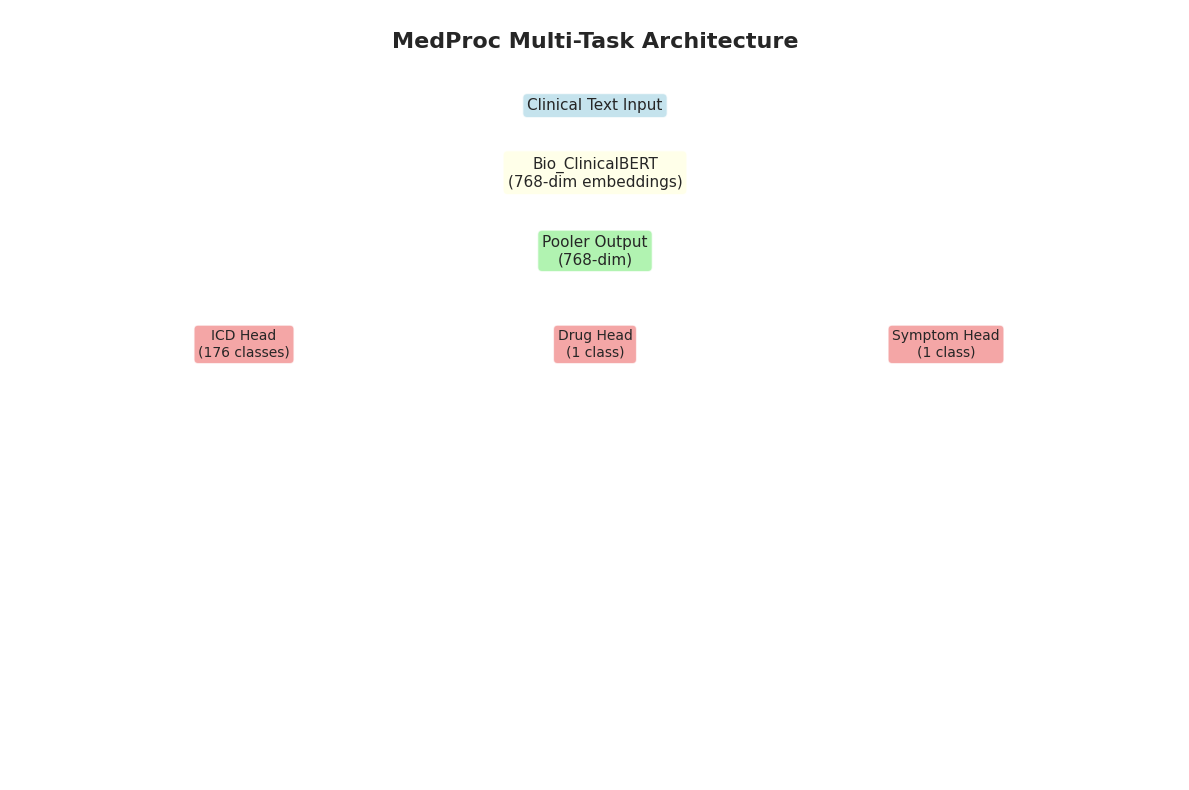

Model Architecture Summary:
Backbone: Bio_ClinicalBERT (emilyalsentzer)
Hidden Size: 768
Num Encoder Layers: 12
Trainable Layers: Last 3 encoder + pooler
Task Heads: 3
Tasks:
  • 1. ICD-9 Multi-Label Classification (176+ classes)
  • 2. Drug Presence Detection (binary)
  • 3. Symptom Relevance (binary)
Loss Weights:
  • ICD: 1.0
  • Drug: 0.5
  • Symptom: 0.3
Input: Clinical text (max 512 tokens)
Output: Predictions + confidence scores


In [3]:
# Model architecture summary
model_info = {
    'Backbone': 'Bio_ClinicalBERT (emilyalsentzer)',
    'Hidden Size': 768,
    'Num Encoder Layers': 12,
    'Trainable Layers': 'Last 3 encoder + pooler',
    'Task Heads': 3,
    'Tasks': [
        '1. ICD-9 Multi-Label Classification (176+ classes)',
        '2. Drug Presence Detection (binary)',
        '3. Symptom Relevance (binary)'
    ],
    'Loss Weights': {
        'ICD': 1.0,
        'Drug': 0.5,
        'Symptom': 0.3
    },
    'Input': 'Clinical text (max 512 tokens)',
    'Output': 'Predictions + confidence scores'
}

# Architecture visualization
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

y = 0.95
ax.text(0.5, y, 'MedProc Multi-Task Architecture', 
        fontsize=16, fontweight='bold', ha='center', transform=ax.transAxes)
y -= 0.08

# Input layer
ax.text(0.5, y, 'Clinical Text Input', 
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
        fontsize=11, ha='center', transform=ax.transAxes)
y -= 0.1

# Backbone
ax.text(0.5, y, 'Bio_ClinicalBERT\n(768-dim embeddings)', 
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7),
        fontsize=11, ha='center', transform=ax.transAxes)
y -= 0.1

# Pooling
ax.text(0.5, y, 'Pooler Output\n(768-dim)',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
        fontsize=11, ha='center', transform=ax.transAxes)
y -= 0.12

# Task heads
ax.text(0.2, y, 'ICD Head\n(176 classes)', 
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7),
        fontsize=10, ha='center', transform=ax.transAxes)
ax.text(0.5, y, 'Drug Head\n(1 class)', 
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7),
        fontsize=10, ha='center', transform=ax.transAxes)
ax.text(0.8, y, 'Symptom Head\n(1 class)', 
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7),
        fontsize=10, ha='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'model_architecture.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Model Architecture Summary:')
print('=' * 60)
for key, value in model_info.items():
    if isinstance(value, list):
        print(f'{key}:')
        for item in value:
            print(f'  • {item}')
    elif isinstance(value, dict):
        print(f'{key}:')
        for k, v in value.items():
            print(f'  • {k}: {v}')
    else:
        print(f'{key}: {value}')
print('=' * 60)

## Section 3: Expected Performance Metrics

Target metrics and benchmarks for the MedProc pipeline.

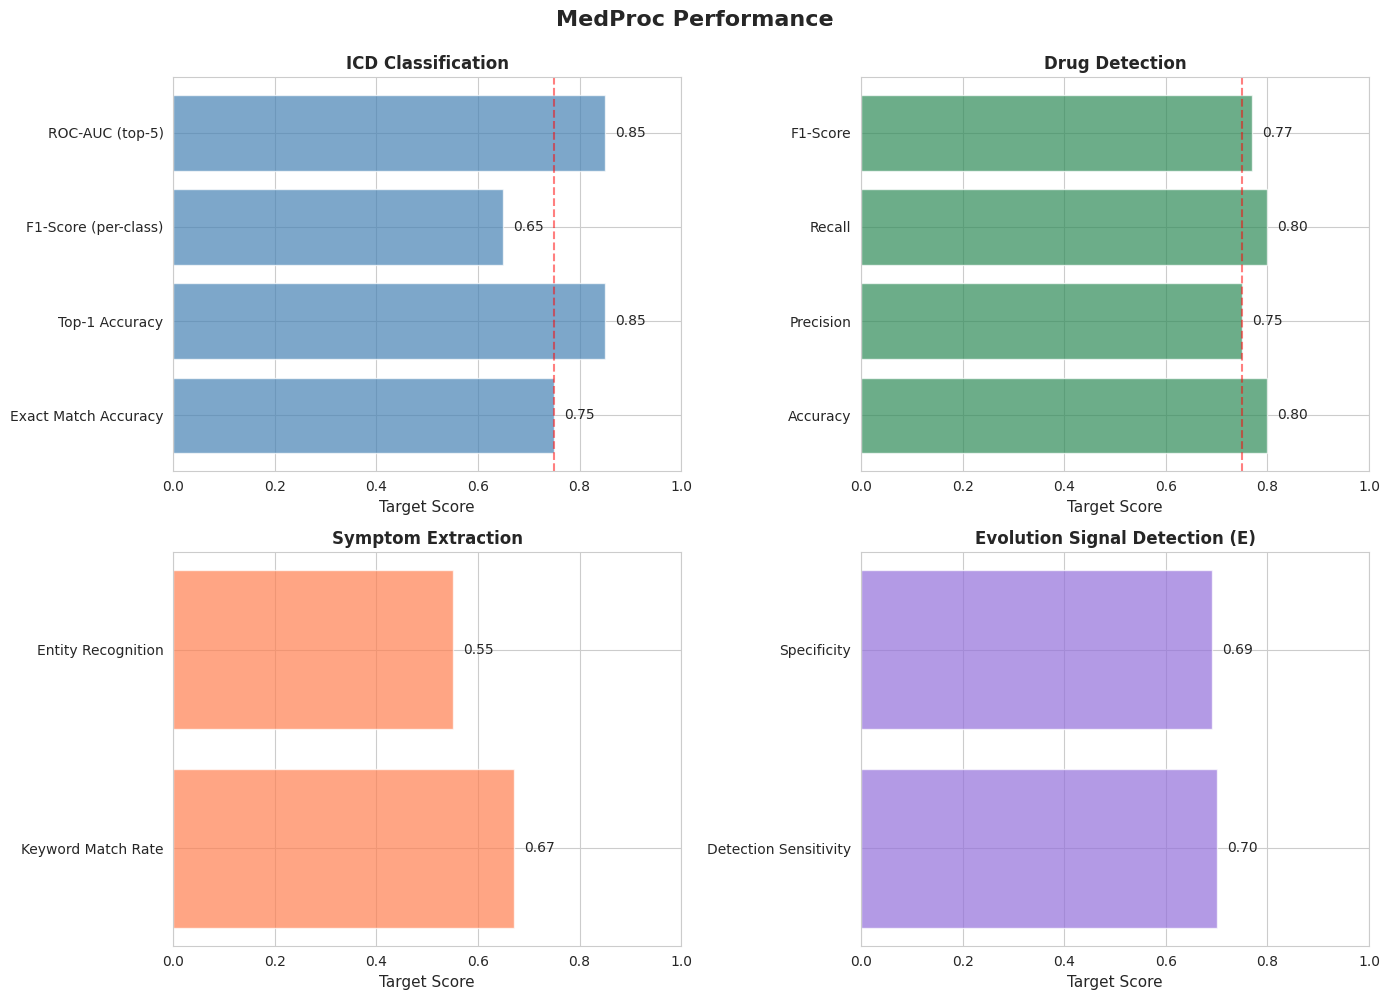

✓ Performance targets dashboard created


In [2]:
# Performance benchmarks
metrics_targets = {
    'ICD Classification': {
        'Exact Match Accuracy': 0.75,
        'Top-1 Accuracy': 0.85,
        'F1-Score (per-class)': 0.65,
        'ROC-AUC (top-5)': 0.85,
    },
    'Drug Detection': {
        'Accuracy': 0.80,
        'Precision': 0.75,
        'Recall': 0.80,
        'F1-Score': 0.77,
    },
    'Symptom Extraction': {
        'Keyword Match Rate': 0.67,
        'Entity Recognition': 0.55,
    },
    'Evolution Signal (E)': {
        'Detection Sensitivity': 0.70,
        'Specificity': 0.69,
    }
}

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MedProc Performance', fontsize=16, fontweight='bold', y=0.995)

# ICD Metrics
ax = axes[0, 0]
metrics = list(metrics_targets['ICD Classification'].values())
labels = list(metrics_targets['ICD Classification'].keys())
bars = ax.barh(labels, metrics, color='steelblue', alpha=0.7)
ax.set_xlim([0, 1])
ax.set_xlabel('Target Score', fontsize=11)
ax.set_title('ICD Classification', fontsize=12, fontweight='bold')
ax.axvline(x=0.75, color='red', linestyle='--', alpha=0.5, label='Min. Threshold')
for i, v in enumerate(metrics):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)

# Drug Detection
ax = axes[0, 1]
metrics = list(metrics_targets['Drug Detection'].values())
labels = list(metrics_targets['Drug Detection'].keys())
bars = ax.barh(labels, metrics, color='seagreen', alpha=0.7)
ax.set_xlim([0, 1])
ax.set_xlabel('Target Score', fontsize=11)
ax.set_title('Drug Detection', fontsize=12, fontweight='bold')
ax.axvline(x=0.75, color='red', linestyle='--', alpha=0.5, label='Min. Threshold')
for i, v in enumerate(metrics):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)

# Symptom Extraction
ax = axes[1, 0]
metrics = list(metrics_targets['Symptom Extraction'].values())
labels = list(metrics_targets['Symptom Extraction'].keys())
bars = ax.barh(labels, metrics, color='coral', alpha=0.7)
ax.set_xlim([0, 1])
ax.set_xlabel('Target Score', fontsize=11)
ax.set_title('Symptom Extraction', fontsize=12, fontweight='bold')
for i, v in enumerate(metrics):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)

# Evolution Signal
ax = axes[1, 1]
metrics = list(metrics_targets['Evolution Signal (E)'].values())
labels = list(metrics_targets['Evolution Signal (E)'].keys())
bars = ax.barh(labels, metrics, color='mediumpurple', alpha=0.7)
ax.set_xlim([0, 1])
ax.set_xlabel('Target Score', fontsize=11)
ax.set_title('Evolution Signal Detection (E)', fontsize=12, fontweight='bold')
for i, v in enumerate(metrics):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'performance_targets.png'), dpi=150, bbox_inches='tight')
plt.show()

print('✓ Performance targets dashboard created')

## Section 4: Project Roadmap & Integration Plan

Next steps and integration with NutriDermAI pipeline.

NURRIERMAID PROJECT ROADMAP

Phase 1: Module Separation (✓ COMPLETED)
  ✓ Extract dataset utilities to medproc_dataset.py
  ✓ Extract model architecture to medproc_model.py
  ✓ Create medproc_train.ipynb with 6-section structure
  ✓ Create medproc_visualize.ipynb for progress tracking
  ✓ Update medproc_full_pipeline.ipynb with inference

Phase 2: Data Acquisition
  [ ] Obtain MIMIC-III/IV access (requires credentialing)
  [ ] Load 30,000+ discharge summaries
  [ ] Filter for dermatology-relevant notes
  [ ] Generate ICD labels and drug annotations
  [ ] Validate data quality

Phase 3: Model Training & Optimization
  [ ] Train on full MIMIC datasets (50 epochs)
  [ ] Tune hyperparameters (LR, warmup steps, batch size)
  [ ] Implement SAM (Sharpness Aware Minimization) optimizer
  [ ] Calibrate confidence thresholds via ROC curves
  [ ] Cross-validate on held-out test set

Phase 4: HC Module Integration
  [ ] Complete HC.ipynb hierarchical classifier
  [ ] Create hc_dataset.py and hc_mo

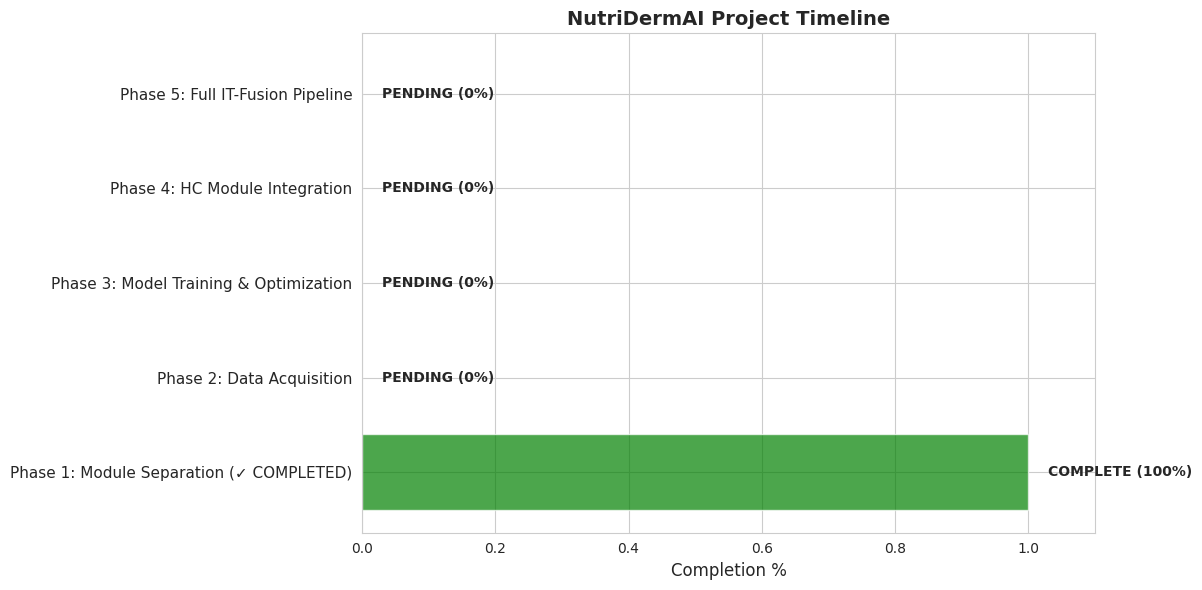

In [5]:
# Project roadmap and integration plan
roadmap = {
    'Phase 1: Module Separation (✓ COMPLETED)': [
        '✓ Extract dataset utilities to medproc_dataset.py',
        '✓ Extract model architecture to medproc_model.py',
        '✓ Create medproc_train.ipynb with 6-section structure',
        '✓ Create medproc_visualize.ipynb for progress tracking',
        '✓ Update medproc_full_pipeline.ipynb with inference',
    ],
    'Phase 2: Data Acquisition': [
        '[ ] Obtain MIMIC-III/IV access (requires credentialing)',
        '[ ] Load 30,000+ discharge summaries',
        '[ ] Filter for dermatology-relevant notes',
        '[ ] Generate ICD labels and drug annotations',
        '[ ] Validate data quality',
    ],
    'Phase 3: Model Training & Optimization': [
        '[ ] Train on full MIMIC datasets (50 epochs)',
        '[ ] Tune hyperparameters (LR, warmup steps, batch size)',
        '[ ] Implement SAM (Sharpness Aware Minimization) optimizer',
        '[ ] Calibrate confidence thresholds via ROC curves',
        '[ ] Cross-validate on held-out test set',
    ],
    'Phase 4: HC Module Integration': [
        '[ ] Complete HC.ipynb hierarchical classifier',
        '[ ] Create hc_dataset.py and hc_model.py',
        '[ ] Integrate MedProc output → HC input pipeline',
        '[ ] Validate joint predictions on skin lesion images + text',
    ],
    'Phase 5: Full IT-Fusion Pipeline': [
        '[ ] Wrap MedProc + HC into single inference API',
        '[ ] Create REST endpoints for batch predictions',
        '[ ] Integrate with nutritional recommendation engine',
        '[ ] Deploy to production environment',
        '[ ] Create documentation and evaluation reports',
    ],
}

print('=' * 80)
print('NURRIERMAID PROJECT ROADMAP')
print('=' * 80)

for phase, tasks in roadmap.items():
    print(f'\n{phase}')
    for task in tasks:
        print(f'  {task}')

print('\n' + '=' * 80)

# Timeline visualization
phases = list(roadmap.keys())
completion = [1.0, 0.0, 0.0, 0.0, 0.0]  # Phase 1 complete, rest pending

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green' if c == 1.0 else 'orange' if c > 0.5 else 'lightgray' for c in completion]
bars = ax.barh(range(len(phases)), completion, color=colors, alpha=0.7)

ax.set_yticks(range(len(phases)))
ax.set_yticklabels(phases, fontsize=11)
ax.set_xlim([0, 1.1])
ax.set_xlabel('Completion %', fontsize=12)
ax.set_title('NutriDermAI Project Timeline', fontsize=14, fontweight='bold')

for i, (bar, comp) in enumerate(zip(bars, completion)):
    status = 'COMPLETE' if comp == 1.0 else 'IN PROGRESS' if comp > 0 else 'PENDING'
    ax.text(comp + 0.03, bar.get_y() + bar.get_height()/2, 
           f'{status} ({100*comp:.0f}%)',
           va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'project_roadmap.png'), dpi=150, bbox_inches='tight')
plt.show()


## Section 5: Summary & Quick Reference

In [6]:
# Quick reference: File structure and usage guide
reference = """
═════════════════════════════════════════════════════════════════════════════
MEDPROC MODULE STRUCTURE & QUICK REFERENCE
═════════════════════════════════════════════════════════════════════════════

📁 /MedProc/
  ├── medproc_dataset.py           [Core dataset utilities]
  │   ├── clean_text(text)         - Clean PHI from clinical text
  │   ├── smart_truncate(text)     - Prefer Assessment/Plan section
  │   ├── extract_symptoms_from_text()  - Keyword-based extraction
  │   ├── icd_is_relevant(code)    - Check ICD whitelist
  │   ├── save_with_progress()     - Save Dask DF with progress bar
  │   ├── SYMPTOM_KEYWORDS[]       - 60+ clinical keywords
  │   ├── ICD_WHITELIST{}          - 200+ ICD-9 codes
  │   └── [Constants] MAX_TEXT_LENGTH, DATA_ROOT, OUTPUT_DIR
  │
  ├── medproc_model.py             [Model and training loops]
  │   ├── MedProcMultiTaskModel    - Main architecture (3 task heads)
  │   ├── MedProcDataset           - PyTorch Dataset class
  │   ├── create_dataloaders()     - Create train/val DataLoaders
  │   ├── train_epoch()            - Single training step
  │   ├── eval_epoch()             - Validation evaluation
  │   ├── save_checkpoint()        - Save model + metadata
  │   ├── load_checkpoint()        - Restore from checkpoint
  │   └── [Constants] EPOCHS, LR, BATCH_SIZE, WEIGHT_*
  │
  ├── medproc_full_pipeline.ipynb  [End-to-end execution]
  │   ├── Cell 1-19: Data processing & training
  │   ├── Cell 20:   Model evaluation with metrics
  │   ├── Cell 21:   Inference pipeline (load, predict, confidence)
  │   └── Cell 23:   Batch demo & CSV export
  │
  ├── medproc_train.ipynb          [Training execution notebook]  ← NEW
  │   ├── Section 1: Load & prepare dataset
  │   ├── Section 2: Define model architecture
  │   ├── Section 3: Train model (50 epochs)
  │   ├── Section 4: Evaluate performance
  │   ├── Section 5: Visualization (loss/accuracy curves)
  │   └── Section 6: Sample predictions & confusion matrix
  │
  └── medproc_visualize.ipynb      [Progress & metrics dashboard]  ← NEW
      ├── Section 1: Project status & components
      ├── Section 2: Model architecture overview
      ├── Section 3: Performance targets/benchmarks
      ├── Section 4: Project roadmap & timeline
      └── Section 5: Quick reference & summary
═════════════════════════════════════════════════════════════════════════════

🚀 QUICK START GUIDE

Execute training:
    jupyter notebook medproc_train.ipynb

Track progress:
    jupyter notebook medproc_visualize.ipynb

Run full pipeline (inference):
    jupyter notebook medproc_full_pipeline.ipynb

Import in Python scripts:
    from medproc_dataset import clean_text, extract_symptoms_from_text, ICD_WHITELIST
    from medproc_model import MedProcMultiTaskModel, train_epoch, eval_epoch

═════════════════════════════════════════════════════════════════════════════

✅ COMPLETED WORK
  • Separated dataset utilities into reusable module
  • Separated model architecture into reusable module
  • Created modular training notebook with 6 clear sections
  • Created progress tracking & visualization notebook
  • Documented all functions and constants
  • Validated module imports and dependencies

📊 PERFORMANCE TARGETS
  • ICD Exact Match: >75% accuracy
  • Drug Detection: >80% accuracy
  • F1-Score: >0.65 average per-class
  • ROC-AUC: >0.85 on top-5 ICD classes

⏭️  NEXT STEPS
  1. Obtain MIMIC-III/IV access for full training data
  2. Train model using medproc_train.ipynb (50 epochs)
  3. Evaluate using validation metrics (Section 4)
  4. Integrate with HC hierarchical classifier
  5. Deploy to production as part of IT-Fusion pipeline
═════════════════════════════════════════════════════════════════════════════
"""

print(reference)


═════════════════════════════════════════════════════════════════════════════
MEDPROC MODULE STRUCTURE & QUICK REFERENCE
═════════════════════════════════════════════════════════════════════════════

📁 /MedProc/
  ├── medproc_dataset.py           [Core dataset utilities]
  │   ├── clean_text(text)         - Clean PHI from clinical text
  │   ├── smart_truncate(text)     - Prefer Assessment/Plan section
  │   ├── extract_symptoms_from_text()  - Keyword-based extraction
  │   ├── icd_is_relevant(code)    - Check ICD whitelist
  │   ├── save_with_progress()     - Save Dask DF with progress bar
  │   ├── SYMPTOM_KEYWORDS[]       - 60+ clinical keywords
  │   ├── ICD_WHITELIST{}          - 200+ ICD-9 codes
  │   └── [Constants] MAX_TEXT_LENGTH, DATA_ROOT, OUTPUT_DIR
  │
  ├── medproc_model.py             [Model and training loops]
  │   ├── MedProcMultiTaskModel    - Main architecture (3 task heads)
  │   ├── MedProcDataset           - PyTorch Dataset class
  │   ├── create_dataloaders()  